In [ ]:
####### NAIVE MODEL ########


Random Forest Model Settings
----------------------------------
n_estimators: 500
max_features: sqrt
max_depth: None
random_state: 42
bootstrap: True
Random Forest Model Evaluation
----------------------------------
R² score: 0.0550
MSE: 0.002025

Additional Evaluation Metrics
----------------------------------
RMSE: 0.044997
MAE:  0.037640


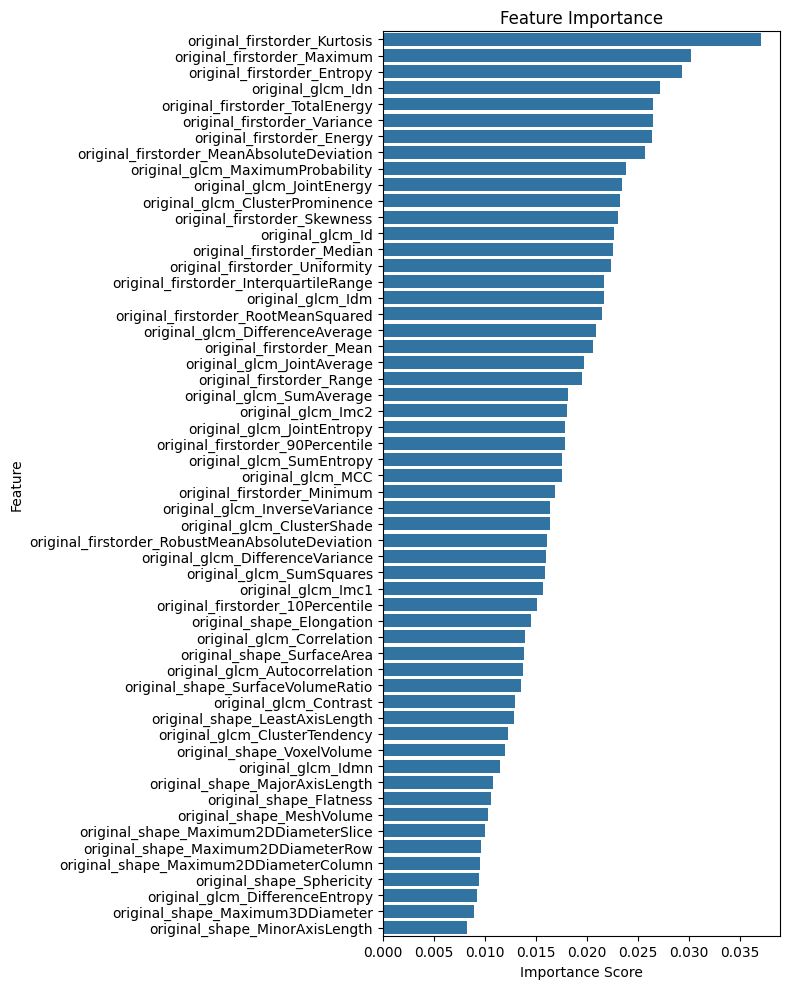

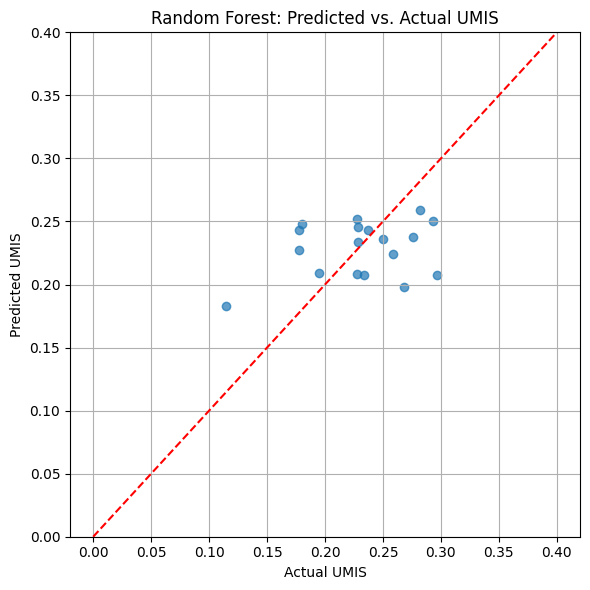

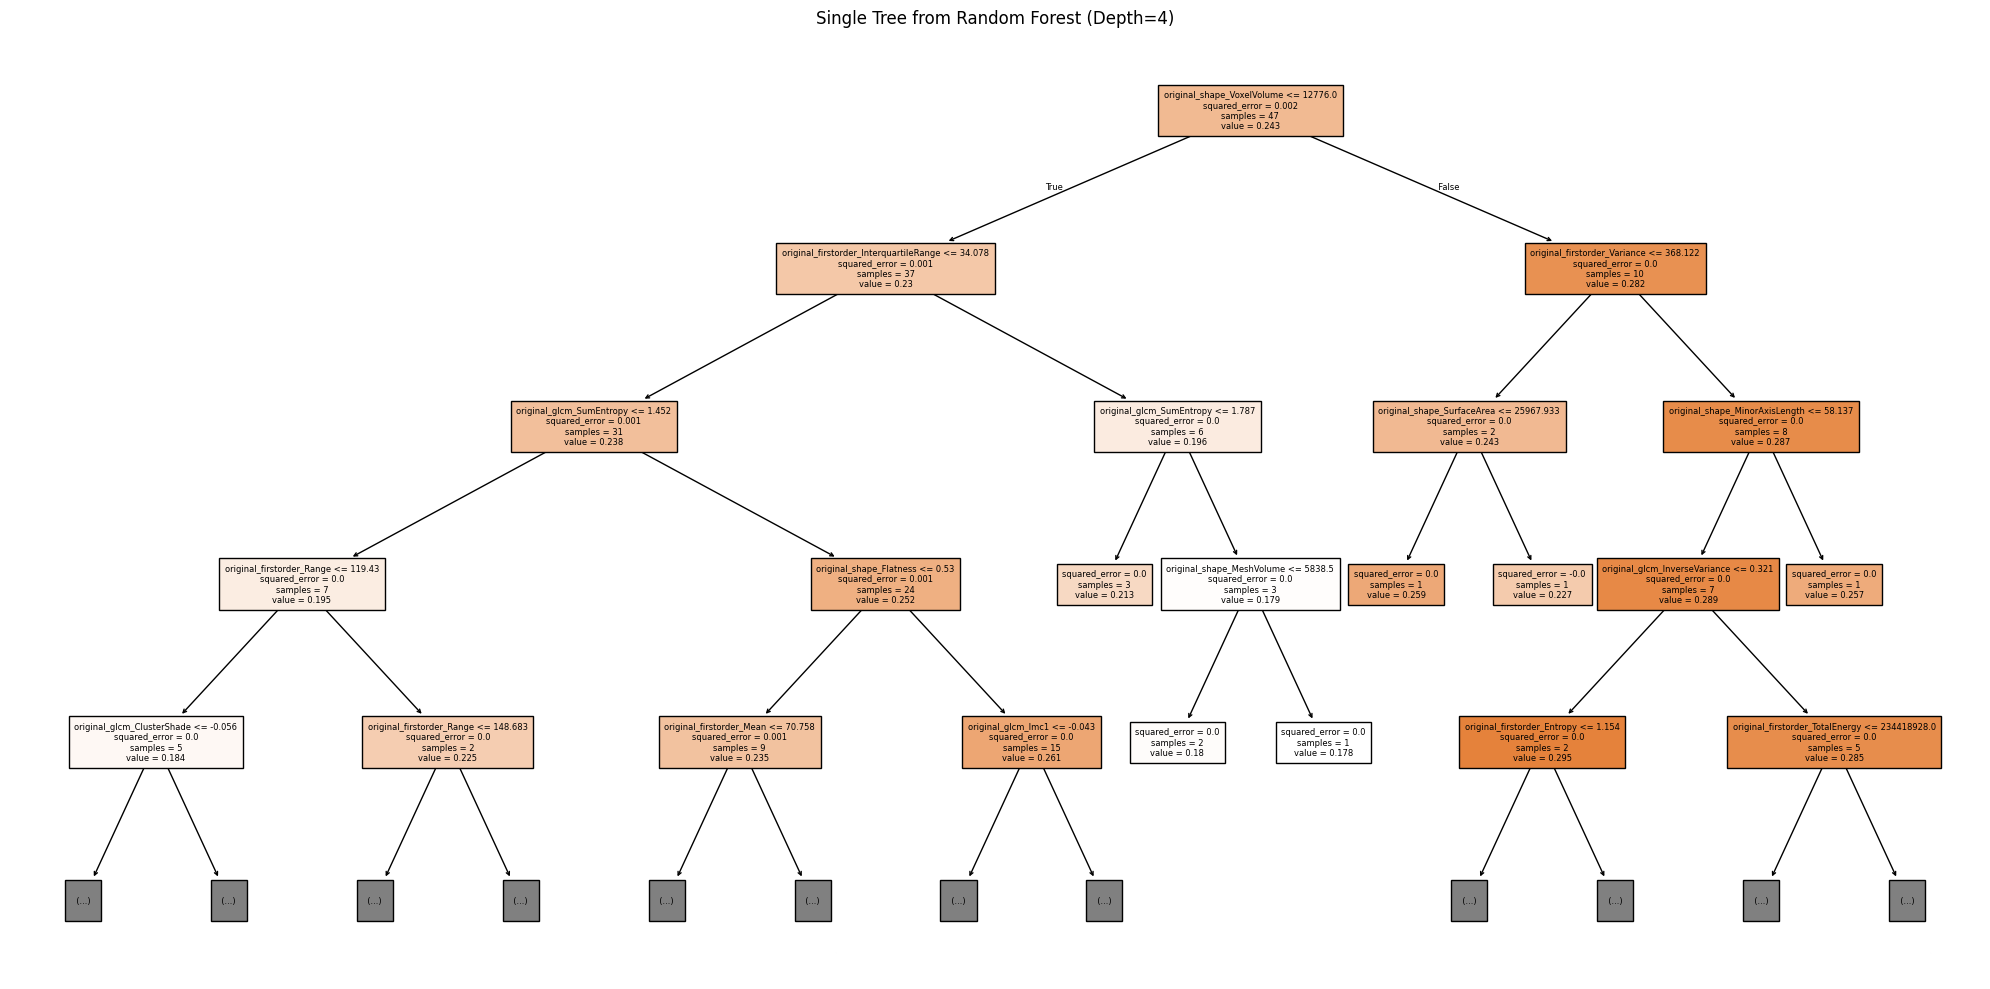

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.tree import plot_tree
from sklearn.metrics import mean_absolute_error
import numpy as np

# Load your Excel file
file_path = "/Users/ryanzeh/Desktop/Feature_Extraction/slim_features_umis_df_params20-12_cb_30-03-25_v1.2.xlsx"
df = pd.read_excel(file_path)

## Random Forest Model Evaluation
## n_estimators: 500
## max_features: sqrt
## max_depth: None
## random_state: 42
## bootstrap: True



# === STEP 1: Filter and define predictors ===
df_filtered = df[df['mask_id'] != 1].copy()

# List of all radiomic features
feature_cols = [
    'original_shape_Elongation', 'original_shape_Flatness', 'original_shape_LeastAxisLength',
    'original_shape_MajorAxisLength', 'original_shape_Maximum2DDiameterColumn',
    'original_shape_Maximum2DDiameterRow', 'original_shape_Maximum2DDiameterSlice',
    'original_shape_Maximum3DDiameter', 'original_shape_MeshVolume', 'original_shape_MinorAxisLength',
    'original_shape_Sphericity', 'original_shape_SurfaceArea', 'original_shape_SurfaceVolumeRatio',
    'original_shape_VoxelVolume', 'original_firstorder_10Percentile', 'original_firstorder_90Percentile',
    'original_firstorder_Energy', 'original_firstorder_Entropy', 'original_firstorder_InterquartileRange',
    'original_firstorder_Kurtosis', 'original_firstorder_Maximum', 'original_firstorder_MeanAbsoluteDeviation',
    'original_firstorder_Mean', 'original_firstorder_Median', 'original_firstorder_Minimum',
    'original_firstorder_Range', 'original_firstorder_RobustMeanAbsoluteDeviation',
    'original_firstorder_RootMeanSquared', 'original_firstorder_Skewness', 'original_firstorder_TotalEnergy',
    'original_firstorder_Uniformity', 'original_firstorder_Variance', 'original_glcm_Autocorrelation',
    'original_glcm_ClusterProminence', 'original_glcm_ClusterShade', 'original_glcm_ClusterTendency',
    'original_glcm_Contrast', 'original_glcm_Correlation', 'original_glcm_DifferenceAverage',
    'original_glcm_DifferenceEntropy', 'original_glcm_DifferenceVariance', 'original_glcm_Id',
    'original_glcm_Idm', 'original_glcm_Idmn', 'original_glcm_Idn', 'original_glcm_Imc1',
    'original_glcm_Imc2', 'original_glcm_InverseVariance', 'original_glcm_JointAverage',
    'original_glcm_JointEnergy', 'original_glcm_JointEntropy', 'original_glcm_MCC',
    'original_glcm_MaximumProbability', 'original_glcm_SumAverage', 'original_glcm_SumEntropy',
    'original_glcm_SumSquares'
]

X = df_filtered[feature_cols]
y = df_filtered['UMIS']

# === STEP 2: Train/test split ===
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# === STEP 3: Train Random Forest ===
rf = RandomForestRegressor(
    n_estimators=500,
    max_features='sqrt',
    max_depth=None,
    random_state=42,
    bootstrap=True
)
rf.fit(X_train, y_train)

# === STEP 4: Predict and evaluate ===
y_pred = rf.predict(X_test)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("\nRandom Forest Model Settings")
print("----------------------------------")
print(f"n_estimators: {rf.n_estimators}")
print(f"max_features: {rf.max_features}")
print(f"max_depth: {rf.max_depth}")
print(f"random_state: {rf.random_state}")
print(f"bootstrap: {rf.bootstrap}")

print("Random Forest Model Evaluation")
print("----------------------------------")
print(f"R² score: {r2:.4f}")
print(f"MSE: {mse:.6f}")

rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print("\nAdditional Evaluation Metrics")
print("----------------------------------")
print(f"RMSE: {rmse:.6f}")
print(f"MAE:  {mae:.6f}")


# === STEP 5: Feature importance plot ===
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8, 10))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# === STEP 6: Predicted vs. actual plot ===
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([0, 0.4], [0, 0.4], color='red', linestyle='--')
plt.xlabel("Actual UMIS")
plt.ylabel("Predicted UMIS")
plt.title("Random Forest: Predicted vs. Actual UMIS")
plt.ylim(0, 0.4)
plt.grid(True)
plt.tight_layout()
plt.show()

# === STEP 7: Visualize a single tree (optional) ===
plt.figure(figsize=(20, 10))
plot_tree(rf.estimators_[0], feature_names=feature_cols, filled=True, max_depth=4, fontsize=6)
plt.title("Single Tree from Random Forest (Depth=4)")
plt.tight_layout()
plt.show()







Random Forest Model Settings
----------------------------------
n_estimators: 500
max_features: 18
max_depth: None
random_state: 42
bootstrap: True

Random Forest Model Evaluation
----------------------------------
R² score: 0.0364
MSE: 0.002065

Additional Evaluation Metrics
----------------------------------
RMSE: 0.039722
MAE:  0.031464


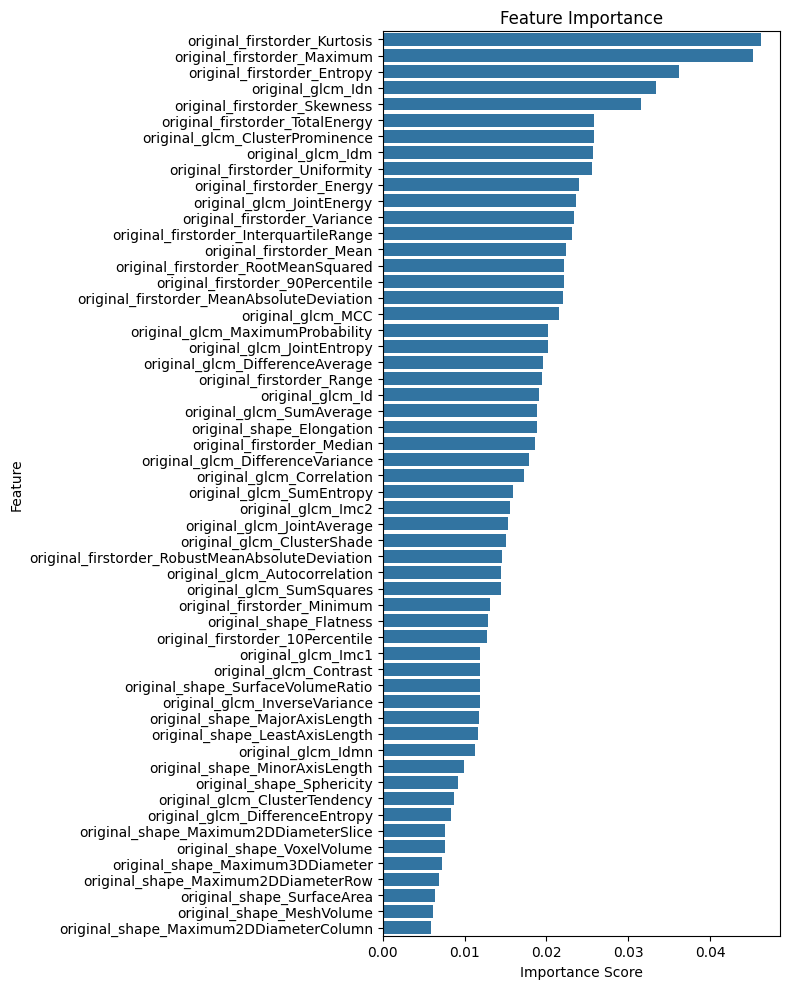

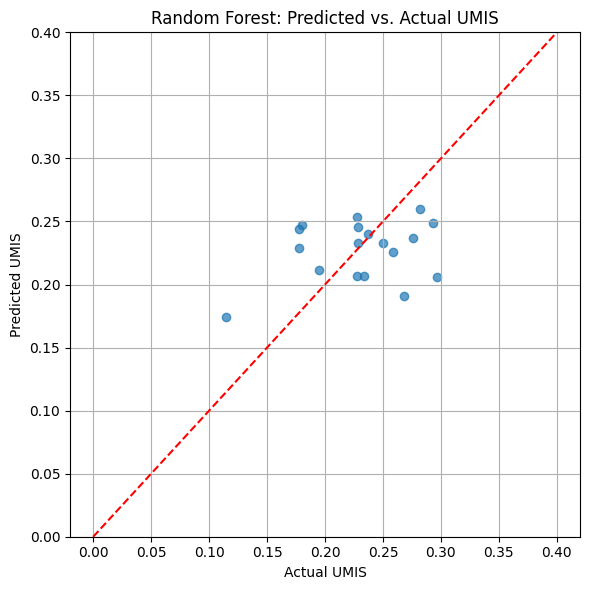

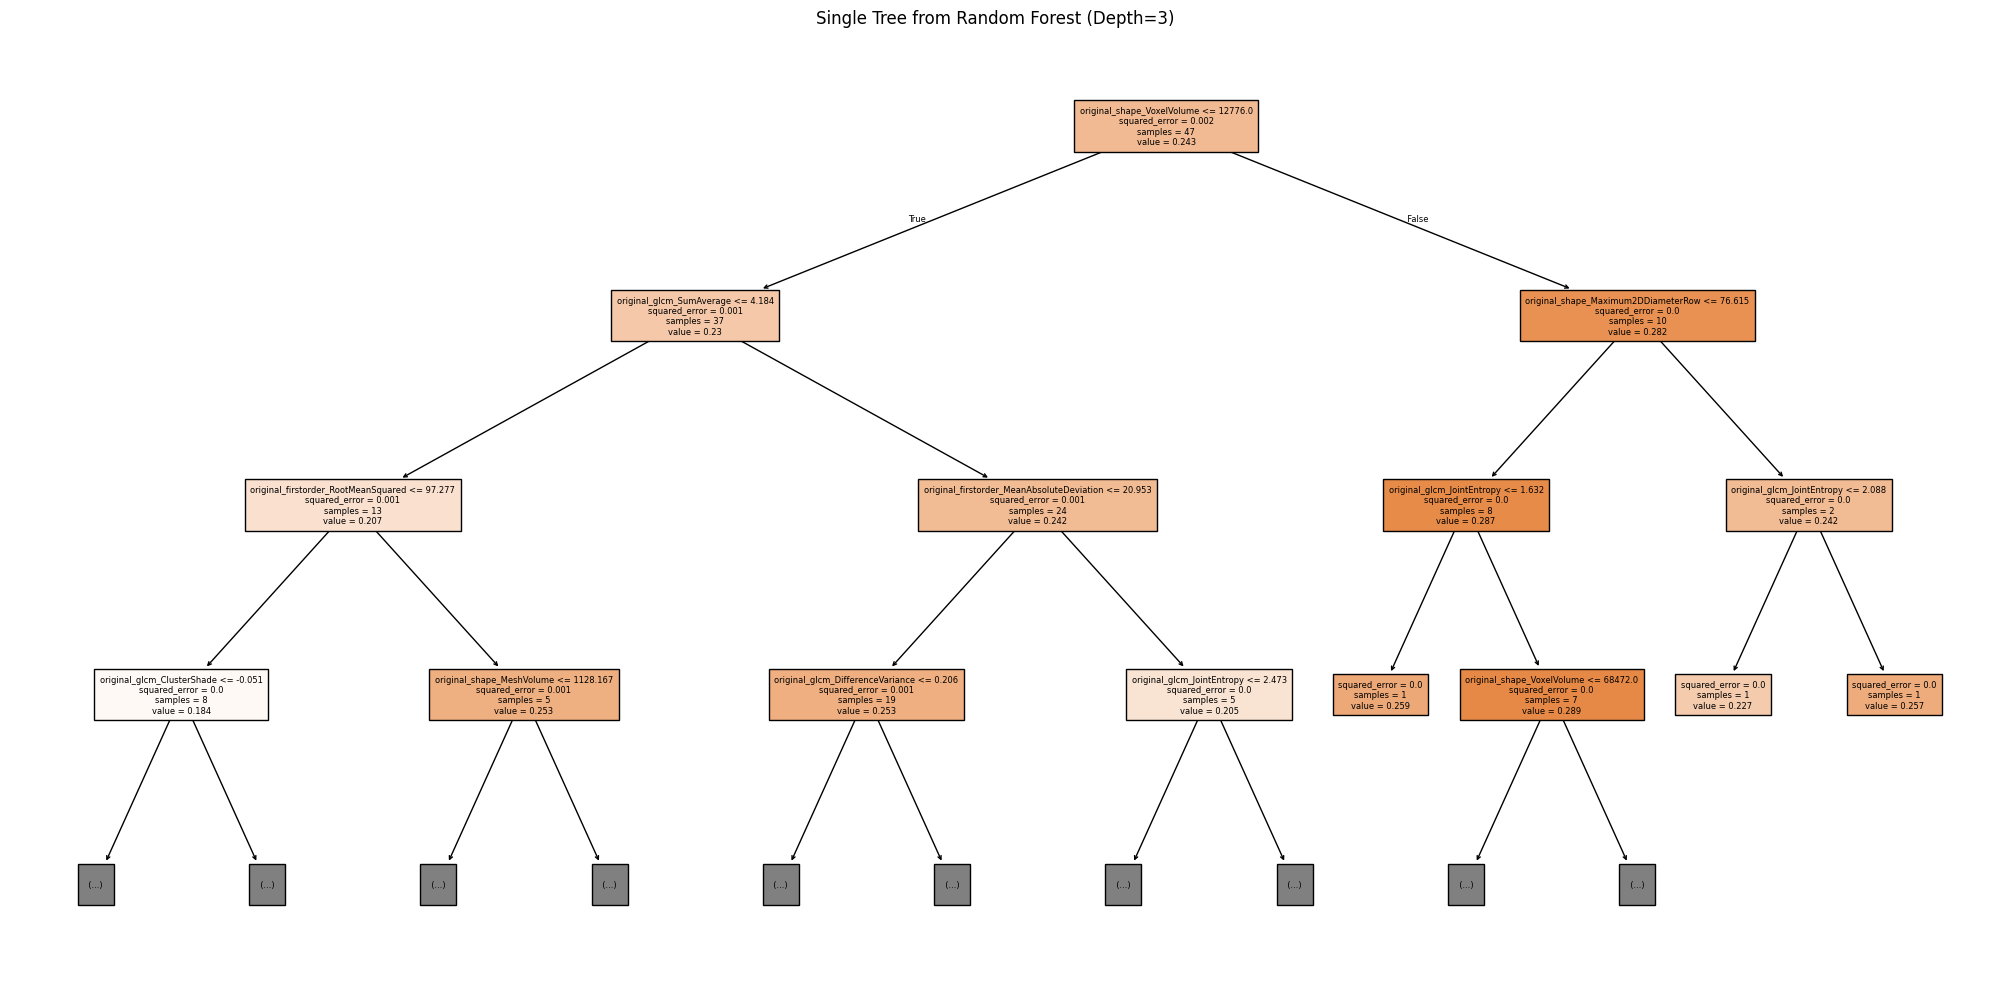

In [10]:
## Random Forest Model Evaluation
## n_estimators: 500
## max_features: Var/3 (18)
## max_depth: None
## random_state: 42
## bootstrap: True

# === STEP 1: Filter and define predictors ===
df_filtered = df[df['mask_id'] != 1].copy()

# List of all radiomic features
feature_cols = [
    'original_shape_Elongation', 'original_shape_Flatness', 'original_shape_LeastAxisLength',
    'original_shape_MajorAxisLength', 'original_shape_Maximum2DDiameterColumn',
    'original_shape_Maximum2DDiameterRow', 'original_shape_Maximum2DDiameterSlice',
    'original_shape_Maximum3DDiameter', 'original_shape_MeshVolume', 'original_shape_MinorAxisLength',
    'original_shape_Sphericity', 'original_shape_SurfaceArea', 'original_shape_SurfaceVolumeRatio',
    'original_shape_VoxelVolume', 'original_firstorder_10Percentile', 'original_firstorder_90Percentile',
    'original_firstorder_Energy', 'original_firstorder_Entropy', 'original_firstorder_InterquartileRange',
    'original_firstorder_Kurtosis', 'original_firstorder_Maximum', 'original_firstorder_MeanAbsoluteDeviation',
    'original_firstorder_Mean', 'original_firstorder_Median', 'original_firstorder_Minimum',
    'original_firstorder_Range', 'original_firstorder_RobustMeanAbsoluteDeviation',
    'original_firstorder_RootMeanSquared', 'original_firstorder_Skewness', 'original_firstorder_TotalEnergy',
    'original_firstorder_Uniformity', 'original_firstorder_Variance', 'original_glcm_Autocorrelation',
    'original_glcm_ClusterProminence', 'original_glcm_ClusterShade', 'original_glcm_ClusterTendency',
    'original_glcm_Contrast', 'original_glcm_Correlation', 'original_glcm_DifferenceAverage',
    'original_glcm_DifferenceEntropy', 'original_glcm_DifferenceVariance', 'original_glcm_Id',
    'original_glcm_Idm', 'original_glcm_Idmn', 'original_glcm_Idn', 'original_glcm_Imc1',
    'original_glcm_Imc2', 'original_glcm_InverseVariance', 'original_glcm_JointAverage',
    'original_glcm_JointEnergy', 'original_glcm_JointEntropy', 'original_glcm_MCC',
    'original_glcm_MaximumProbability', 'original_glcm_SumAverage', 'original_glcm_SumEntropy',
    'original_glcm_SumSquares'
]

X = df_filtered[feature_cols]
y = df_filtered['UMIS']

# === STEP 2: Train/test split ===
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# === STEP 3: Train Random Forest (max_features = 56 // 3 = 18) ===
rf = RandomForestRegressor(
    n_estimators=500,
    max_features=18,
    max_depth=None,
    random_state=42,
    bootstrap=True
)
rf.fit(X_train, y_train)

# === Print model settings ===
print("\nRandom Forest Model Settings")
print("----------------------------------")
print(f"n_estimators: {rf.n_estimators}")
print(f"max_features: {rf.max_features}")
print(f"max_depth: {rf.max_depth}")
print(f"random_state: {rf.random_state}")
print(f"bootstrap: {rf.bootstrap}")

# === STEP 4: Predict and evaluate ===
y_pred = rf.predict(X_test)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("\nRandom Forest Model Evaluation")
print("----------------------------------")
print(f"R² score: {r2:.4f}")
print(f"MSE: {mse:.6f}")
print("\nAdditional Evaluation Metrics")
print("----------------------------------")
print(f"RMSE: {rmse:.6f}")
print(f"MAE:  {mae:.6f}")

# === STEP 5: Feature importance plot ===
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8, 10))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# === STEP 6: Predicted vs. actual plot ===
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([0, 0.4], [0, 0.4], color='red', linestyle='--')
plt.xlabel("Actual UMIS")
plt.ylabel("Predicted UMIS")
plt.title("Random Forest: Predicted vs. Actual UMIS")
plt.ylim(0, 0.4)
plt.grid(True)
plt.tight_layout()
plt.show()

# === STEP 7: Visualize a single decision tree (from the forest) ===
plt.figure(figsize=(20, 10))
plot_tree(rf.estimators_[0], feature_names=feature_cols, filled=True, max_depth=3, fontsize=6)
plt.title("Single Tree from Random Forest (Depth=3)")
plt.tight_layout()
plt.show()



🛠️ Random Forest Model Settings
----------------------------------
n_estimators: 1000
max_features: 18
max_depth: None
random_state: 42
bootstrap: True

🌲 Random Forest Model Evaluation
----------------------------------
R² score: 0.0526
MSE: 0.002030


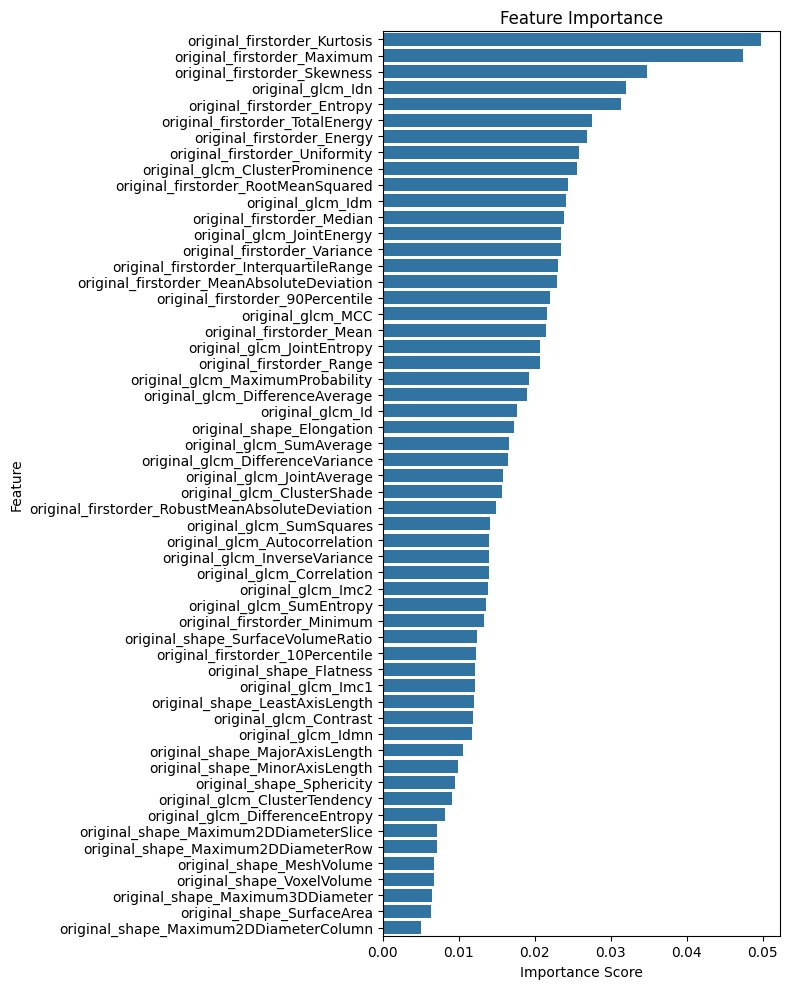

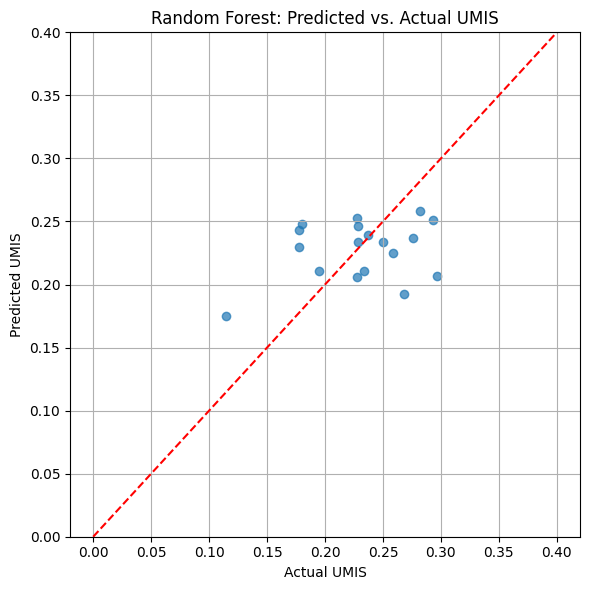

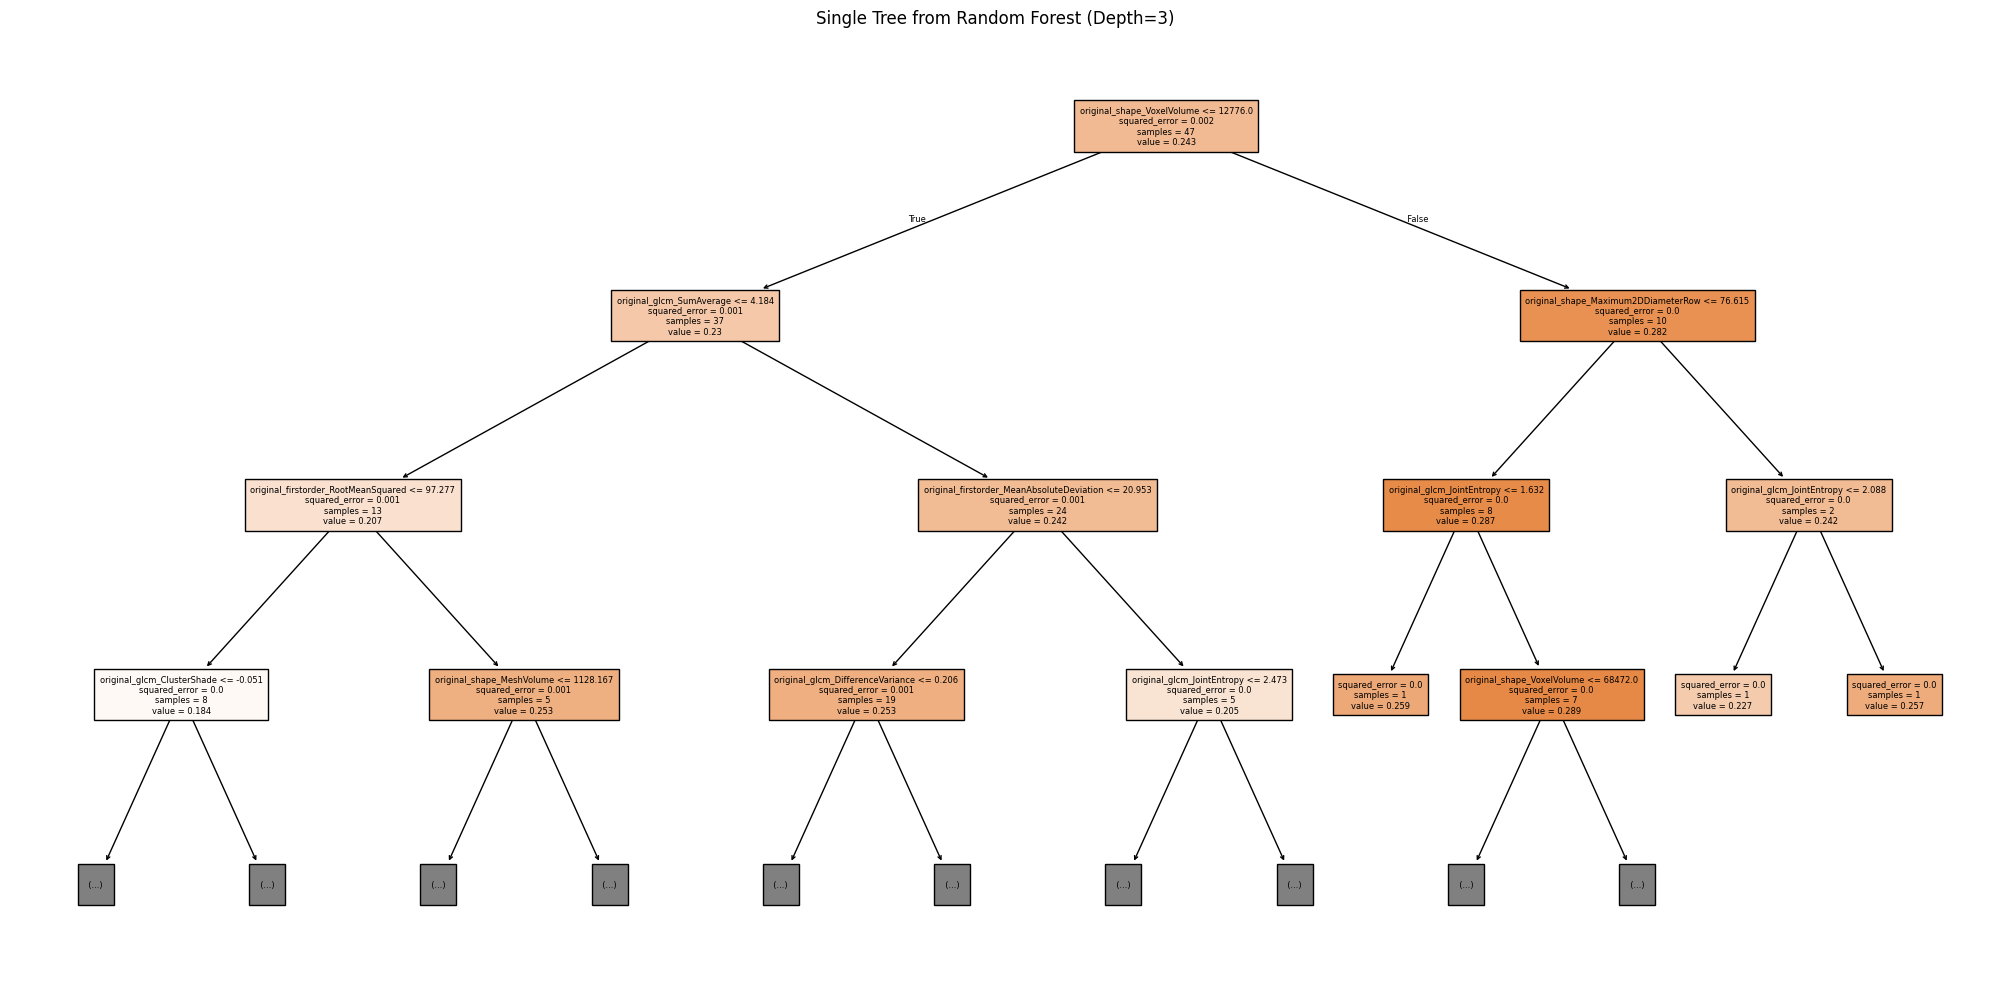

In [7]:
## Random Forest Model Evaluation
## n_estimators: 1000
## max_features: Var/3 (18)
## max_depth: None
## random_state: 42
## bootstrap: True

# === STEP 1: Filter and define predictors ===
df_filtered = df[df['mask_id'] != 1].copy()

# List of all radiomic features
feature_cols = [
    'original_shape_Elongation', 'original_shape_Flatness', 'original_shape_LeastAxisLength',
    'original_shape_MajorAxisLength', 'original_shape_Maximum2DDiameterColumn',
    'original_shape_Maximum2DDiameterRow', 'original_shape_Maximum2DDiameterSlice',
    'original_shape_Maximum3DDiameter', 'original_shape_MeshVolume', 'original_shape_MinorAxisLength',
    'original_shape_Sphericity', 'original_shape_SurfaceArea', 'original_shape_SurfaceVolumeRatio',
    'original_shape_VoxelVolume', 'original_firstorder_10Percentile', 'original_firstorder_90Percentile',
    'original_firstorder_Energy', 'original_firstorder_Entropy', 'original_firstorder_InterquartileRange',
    'original_firstorder_Kurtosis', 'original_firstorder_Maximum', 'original_firstorder_MeanAbsoluteDeviation',
    'original_firstorder_Mean', 'original_firstorder_Median', 'original_firstorder_Minimum',
    'original_firstorder_Range', 'original_firstorder_RobustMeanAbsoluteDeviation',
    'original_firstorder_RootMeanSquared', 'original_firstorder_Skewness', 'original_firstorder_TotalEnergy',
    'original_firstorder_Uniformity', 'original_firstorder_Variance', 'original_glcm_Autocorrelation',
    'original_glcm_ClusterProminence', 'original_glcm_ClusterShade', 'original_glcm_ClusterTendency',
    'original_glcm_Contrast', 'original_glcm_Correlation', 'original_glcm_DifferenceAverage',
    'original_glcm_DifferenceEntropy', 'original_glcm_DifferenceVariance', 'original_glcm_Id',
    'original_glcm_Idm', 'original_glcm_Idmn', 'original_glcm_Idn', 'original_glcm_Imc1',
    'original_glcm_Imc2', 'original_glcm_InverseVariance', 'original_glcm_JointAverage',
    'original_glcm_JointEnergy', 'original_glcm_JointEntropy', 'original_glcm_MCC',
    'original_glcm_MaximumProbability', 'original_glcm_SumAverage', 'original_glcm_SumEntropy',
    'original_glcm_SumSquares'
]

X = df_filtered[feature_cols]
y = df_filtered['UMIS']

# === STEP 2: Train/test split ===
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# === STEP 3: Train Random Forest (max_features = 56 // 3 = 18) ===
rf = RandomForestRegressor(
    n_estimators=1000,
    max_features=18,
    max_depth=None,
    random_state=42,
    bootstrap=True
)
rf.fit(X_train, y_train)

# === Print model settings ===
print("\n🛠️ Random Forest Model Settings")
print("----------------------------------")
print(f"n_estimators: {rf.n_estimators}")
print(f"max_features: {rf.max_features}")
print(f"max_depth: {rf.max_depth}")
print(f"random_state: {rf.random_state}")
print(f"bootstrap: {rf.bootstrap}")

# === STEP 4: Predict and evaluate ===
y_pred = rf.predict(X_test)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("\n🌲 Random Forest Model Evaluation")
print("----------------------------------")
print(f"R² score: {r2:.4f}")
print(f"MSE: {mse:.6f}")

# === STEP 5: Feature importance plot ===
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8, 10))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# === STEP 6: Predicted vs. actual plot ===
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([0, 0.4], [0, 0.4], color='red', linestyle='--')
plt.xlabel("Actual UMIS")
plt.ylabel("Predicted UMIS")
plt.title("Random Forest: Predicted vs. Actual UMIS")
plt.ylim(0, 0.4)
plt.grid(True)
plt.tight_layout()
plt.show()

# === STEP 7: Visualize a single decision tree (from the forest) ===
plt.figure(figsize=(20, 10))
plot_tree(rf.estimators_[0], feature_names=feature_cols, filled=True, max_depth=3, fontsize=6)
plt.title("Single Tree from Random Forest (Depth=3)")
plt.tight_layout()
plt.show()

In [ ]:
####### PATIENT AVERAGE MODEL #######




####### PATIENT AVERAGE MODEL #######




####### PATIENT AVERAGE MODEL #######




####### PATIENT AVERAGE MODEL #######


Random Forest Model Settings
-----------------------------
n_estimators: 500
max_features: 18
max_depth: None
random_state: 42
bootstrap: True

Patient-Level Model Evaluation
------------------------------
R² score: 0.2030
MSE: 0.001528
RMSE: 0.039089
MAE:  0.030769


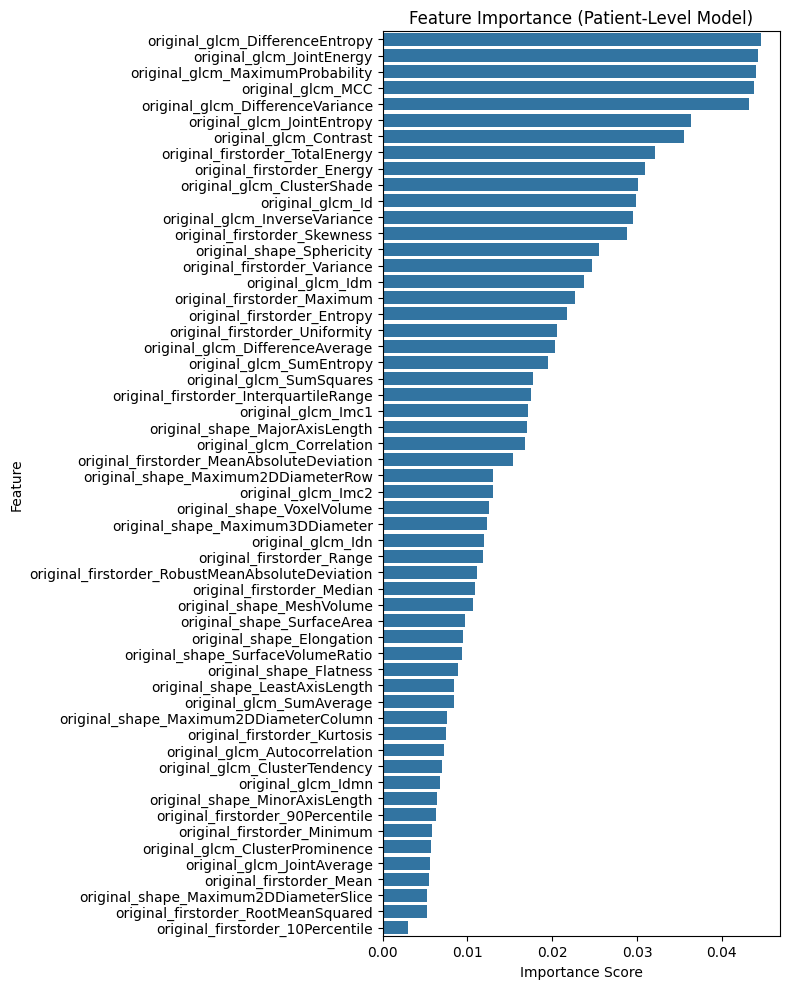

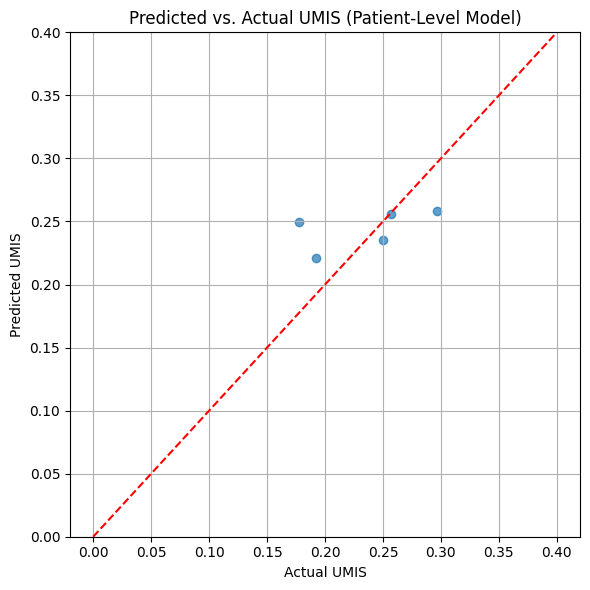

In [4]:

# === STEP 2: Filter out mask_id == 1 ===
df_filtered = df[df['mask_id'] != 1].copy()

# === STEP 3: Group by PatientID and average all features (including UMIS) ===
grouped = df_filtered.groupby('PatientID').mean(numeric_only=True).reset_index()

# === STEP 4: Define features and target ===
feature_cols = [col for col in grouped.columns if col not in ['PatientID', 'UMIS', 'mask_id']]
X = grouped[feature_cols]
y = grouped['UMIS']

# === STEP 5: Train/test split ===
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# === STEP 6: Train Random Forest ===
rf = RandomForestRegressor(
    n_estimators=500,
    max_features=18,
    max_depth=None,
    random_state=42,
    bootstrap=True
)
rf.fit(X_train, y_train)

# === STEP 7: Print model settings ===
print("\nRandom Forest Model Settings")
print("-----------------------------")
print(f"n_estimators: {rf.n_estimators}")
print(f"max_features: {rf.max_features}")
print(f"max_depth: {rf.max_depth}")
print(f"random_state: {rf.random_state}")
print(f"bootstrap: {rf.bootstrap}")

# === STEP 8: Predict and evaluate ===
y_pred = rf.predict(X_test)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print("\nPatient-Level Model Evaluation")
print("------------------------------")
print(f"R² score: {r2:.4f}")
print(f"MSE: {mse:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"MAE:  {mae:.6f}")

# === STEP 9: Feature importance plot ===
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8, 10))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title("Feature Importance (Patient-Level Model)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# === STEP 10: Predicted vs. actual plot ===
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([0, 0.4], [0, 0.4], color='red', linestyle='--')
plt.xlabel("Actual UMIS")
plt.ylabel("Predicted UMIS")
plt.title("Predicted vs. Actual UMIS (Patient-Level Model)")
plt.ylim(0, 0.4)
plt.grid(True)
plt.tight_layout()
plt.show()



Random Forest Model Settings
-----------------------------
n_estimators: 1000
max_features: sqrt
max_depth: None
random_state: 42
bootstrap: True

Patient-Level Model Evaluation
------------------------------
R² score: 0.1770
MSE: 0.001578
RMSE: 0.039722
MAE:  0.031464


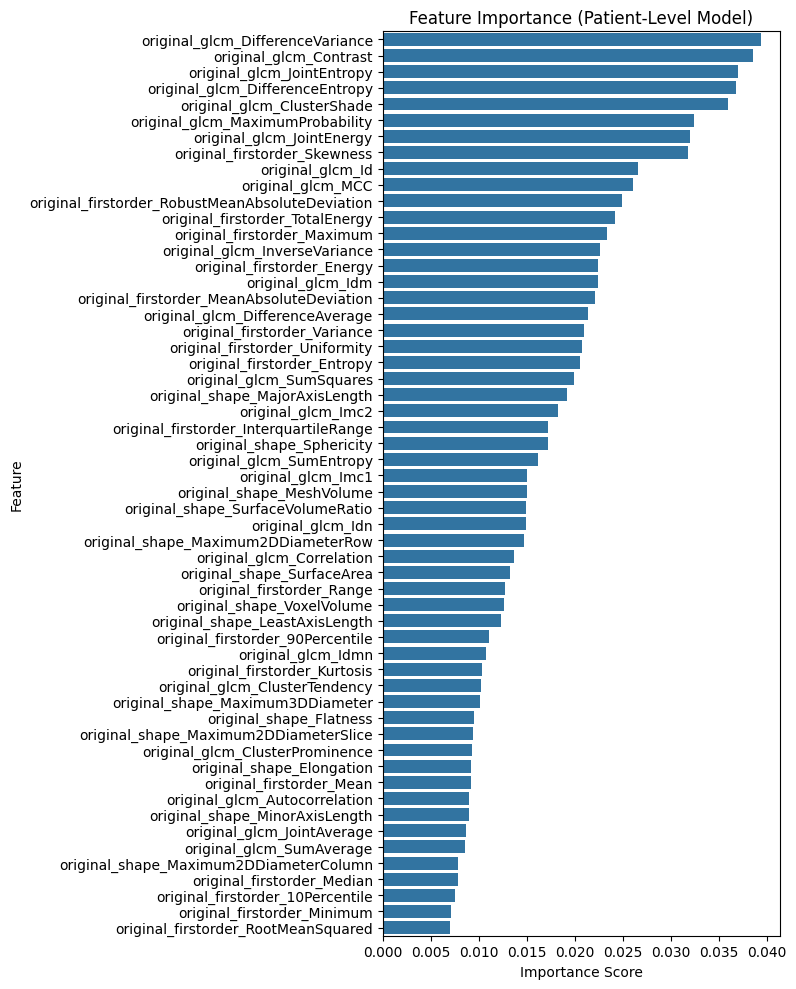

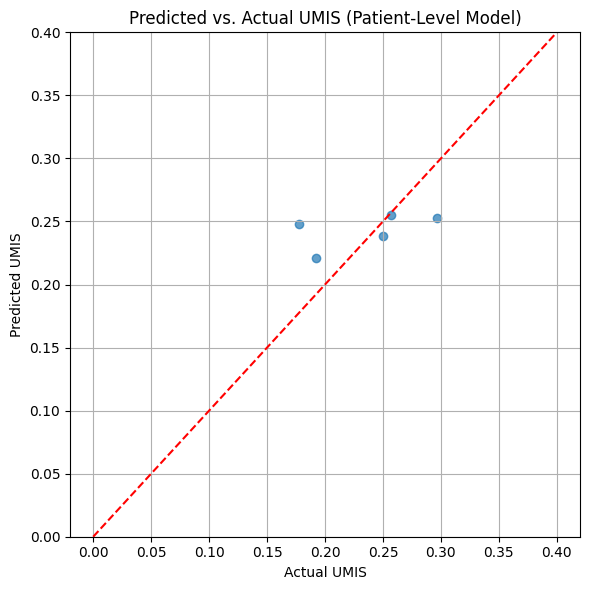

In [14]:

# === STEP 2: Filter out mask_id == 1 ===
df_filtered = df[df['mask_id'] != 1].copy()

# === STEP 3: Group by PatientID and average all features (including UMIS) ===
grouped = df_filtered.groupby('PatientID').mean(numeric_only=True).reset_index()

# === STEP 4: Define features and target ===
feature_cols = [col for col in grouped.columns if col not in ['PatientID', 'UMIS', 'mask_id']]
X = grouped[feature_cols]
y = grouped['UMIS']

# === STEP 5: Train/test split ===
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# === STEP 6: Train Random Forest ===
rf = RandomForestRegressor(
    n_estimators=1000,
    max_features= 'sqrt',
    max_depth=None,
    random_state=42,
    bootstrap=True
)
rf.fit(X_train, y_train)

# === STEP 7: Print model settings ===
print("\nRandom Forest Model Settings")
print("-----------------------------")
print(f"n_estimators: {rf.n_estimators}")
print(f"max_features: {rf.max_features}")
print(f"max_depth: {rf.max_depth}")
print(f"random_state: {rf.random_state}")
print(f"bootstrap: {rf.bootstrap}")

# === STEP 8: Predict and evaluate ===
y_pred = rf.predict(X_test)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print("\nPatient-Level Model Evaluation")
print("------------------------------")
print(f"R² score: {r2:.4f}")
print(f"MSE: {mse:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"MAE:  {mae:.6f}")

# === STEP 9: Feature importance plot ===
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8, 10))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title("Feature Importance (Patient-Level Model)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# === STEP 10: Predicted vs. actual plot ===
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([0, 0.4], [0, 0.4], color='red', linestyle='--')
plt.xlabel("Actual UMIS")
plt.ylabel("Predicted UMIS")
plt.title("Predicted vs. Actual UMIS (Patient-Level Model)")
plt.ylim(0, 0.4)
plt.grid(True)
plt.tight_layout()
plt.show()


Top features by Intra/Inter variance ratio:
                           Feature     Intra_var     Inter_var  \
0    original_glcm_Autocorrelation  2.489032e+03  1.128905e+03   
1     original_firstorder_Kurtosis  8.926128e+01  4.131943e+01   
2        original_shape_MeshVolume  3.676586e+09  1.780750e+09   
3       original_shape_VoxelVolume  3.687544e+09  1.807514e+09   
4       original_glcm_ClusterShade  8.315791e+01  4.142137e+01   
5       original_glcm_JointAverage  5.246429e+00  2.615724e+00   
6         original_glcm_SumAverage  2.098572e+01  1.046290e+01   
7  original_glcm_ClusterProminence  1.422529e+05  7.102976e+04   
8     original_firstorder_Variance  1.015522e+06  5.084449e+05   
9        original_firstorder_Range  1.543755e+04  7.961915e+03   

   Intra/Inter Ratio  
0           2.204820  
1           2.160273  
2           2.064628  
3           2.040119  
4           2.007609  
5           2.005727  
6           2.005727  
7           2.002722  
8           1.997311  

/var/folders/fg/47_r1cc57vxg8_wn3z8nz2h00000gn/T/ipykernel_27235/2091520126.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_masked[f'{feature}_intra'] = (df_masked[feature] - df_masked[f'{feature}_pt_mean']) ** 2
/var/folders/fg/47_r1cc57vxg8_wn3z8nz2h00000gn/T/ipykernel_27235/2091520126.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_masked[f'{feature}_pt_mean'] = df_masked['PatientID'].map(patient_means)
/var/folders/fg/47_r1cc57vxg8_wn3z8nz2h00000gn/T/ipykernel_27235/2091520126.py:25: PerformanceWarning: DataF

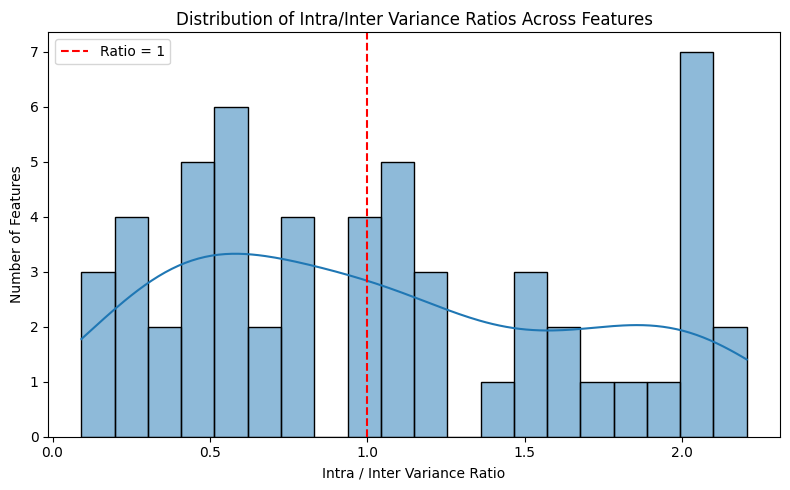

In [22]:
###Variance component analysis // inter/intrasubject variablility analyssis
import pandas as pd
import numpy as np

# === STEP 1: Filter out mask_id == 1 ===
df_masked = df[df['mask_id'] != 1].copy()

# === STEP 2: Define feature columns (exclude identifiers and UMIS) ===
feature_cols = [col for col in df_masked.columns if col not in ['PatientID', 'mask_id', 'UMIS']]
# Keep only numeric columns to avoid TypeError
feature_cols = [col for col in feature_cols if pd.api.types.is_numeric_dtype(df_masked[col])]


# === STEP 3: Prepare storage for results ===
results = []

for feature in feature_cols:
    # Compute patient-wise means
    patient_means = df_masked.groupby('PatientID')[feature].mean()
    
    # Map patient means back to each mask row
    df_masked[f'{feature}_pt_mean'] = df_masked['PatientID'].map(patient_means)
    
    # Intra-subject variance (squared deviations from patient mean)
    df_masked[f'{feature}_intra'] = (df_masked[feature] - df_masked[f'{feature}_pt_mean']) ** 2
    intra_var = df_masked.groupby('PatientID')[f'{feature}_intra'].mean().mean()
    
    # Inter-subject variance (variance of patient means)
    inter_var = patient_means.var()
    
    # Store results
    results.append({
        'Feature': feature,
        'Intra_var': intra_var,
        'Inter_var': inter_var,
        'Intra/Inter Ratio': intra_var / inter_var if inter_var > 0 else np.nan
    })

# === STEP 4: Create and sort results DataFrame ===
var_df = pd.DataFrame(results)
var_df_sorted = var_df.sort_values(by='Intra/Inter Ratio', ascending=False).reset_index(drop=True)

# === STEP 5: Display results ===
print("Top features by Intra/Inter variance ratio:")
print(var_df_sorted.head(10))  # or use .to_string() for full display

# Optional: Save to Excel or CSV if you'd like
#output_path = "/Users/ryanzeh/Desktop/inter_intra_variability_results.xlsx"
#var_df_sorted.to_excel(output_path, index=False)
#print(f"\n✅ Results saved to: {output_path}")


import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Select top 2 most variable (highest ratio) and bottom 2 least variable (lowest ratio) features
top2_features = var_df_sorted.head(2)
bottom2_features = var_df_sorted.tail(2)
annotated_features = pd.concat([top2_features, bottom2_features])


#histogrma
plt.figure(figsize=(8, 5))
sns.histplot(var_df['Intra/Inter Ratio'], bins=20, kde=True)
plt.title("Distribution of Intra/Inter Variance Ratios Across Features")
plt.xlabel("Intra / Inter Variance Ratio")
plt.ylabel("Number of Features")
plt.axvline(1.0, color='red', linestyle='--', label='Ratio = 1')
plt.legend()
plt.tight_layout()
plt.show()






